# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    candidates = [
        os.path.join(DATA_DIR, filename),
        os.path.join("lab_data", filename),
        filename,
    ]
    path = next((p for p in candidates if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError(
            "Không tìm thấy '" + filename + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)


pandas 3.0.6 | numpy 2.4.6 | matplotlib 3.11.2 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

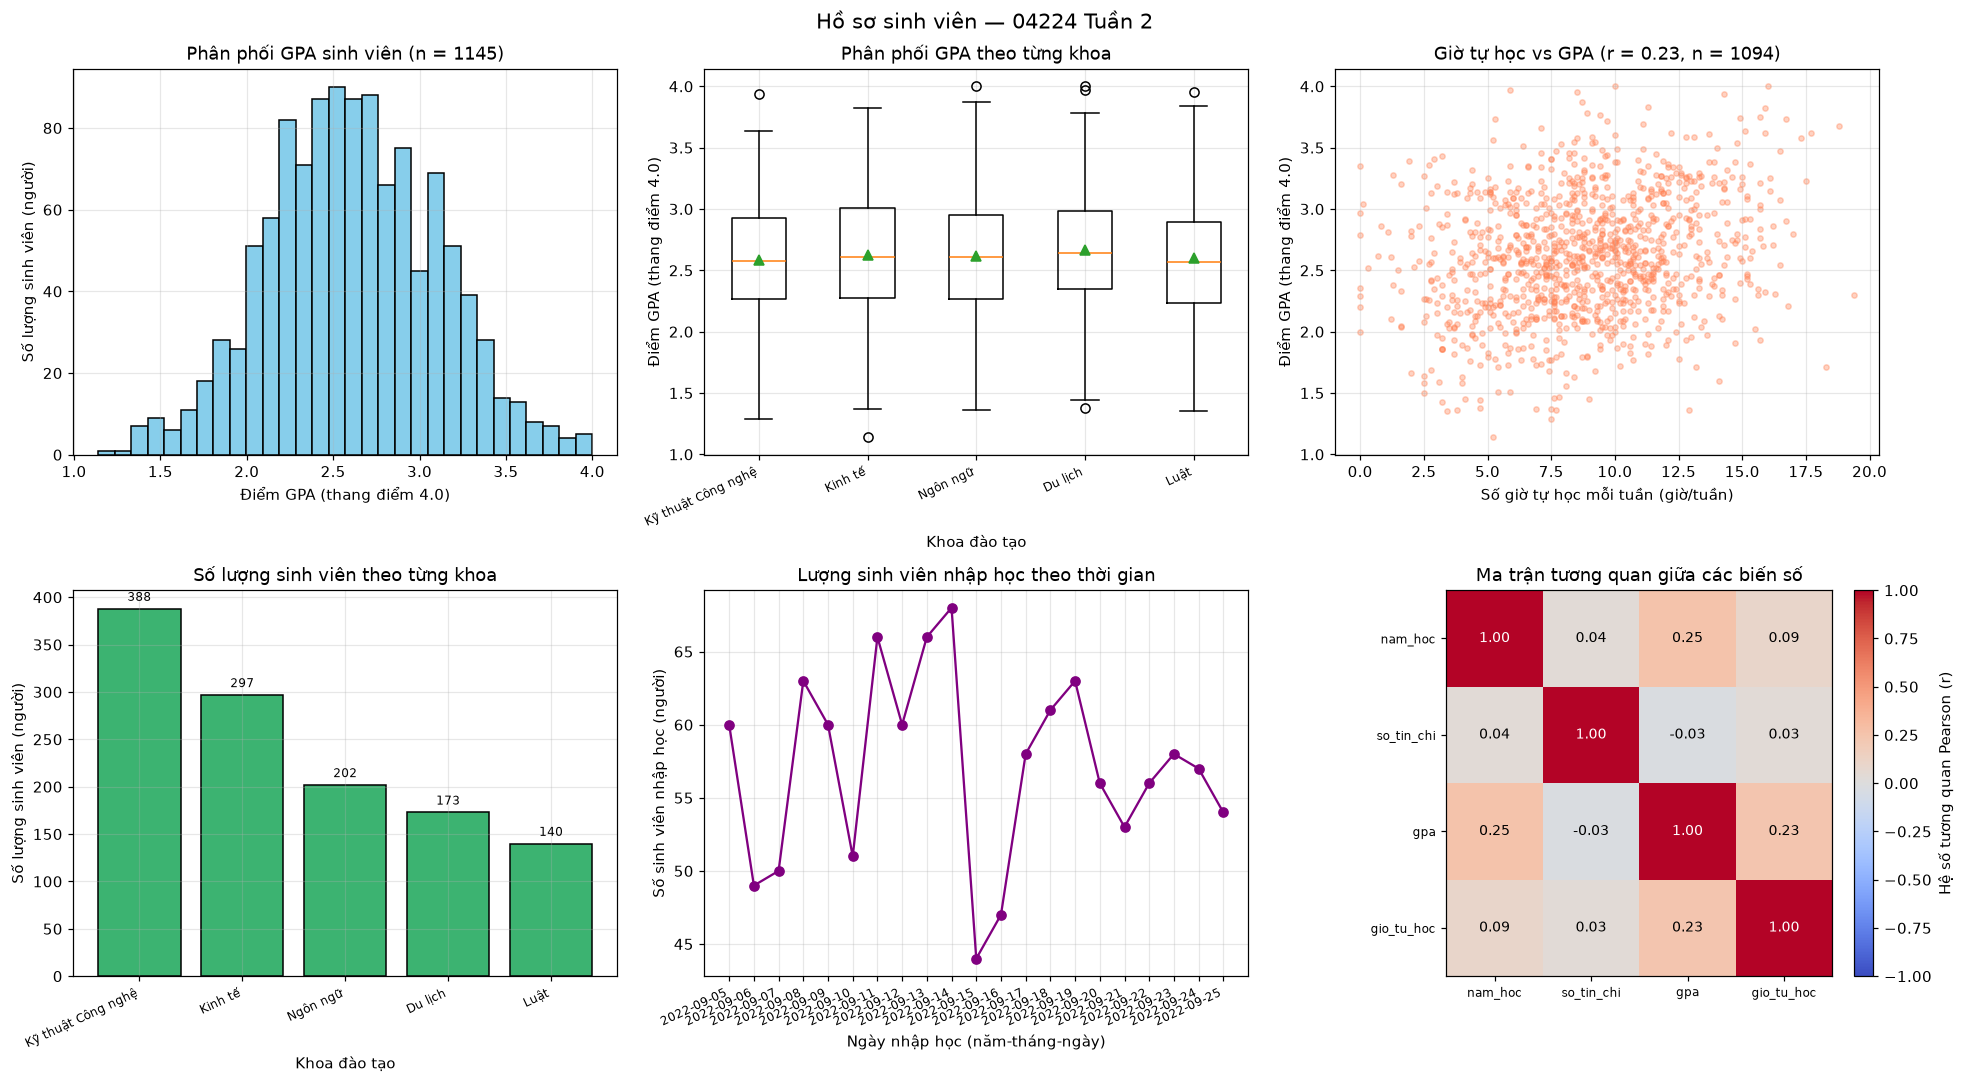

In [2]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
ax.hist(sv_gpa["gpa"], bins=30, edgecolor="black", color="skyblue")
ax.set_xlabel("Điểm GPA (thang điểm 4.0)")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title(f"Phân phối GPA sinh viên (n = {len(sv_gpa)})")

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
gpa_by_fac = [sv_gpa.loc[sv_gpa["khoa"] == fac, "gpa"].values for fac in faculties]
ax.boxplot(gpa_by_fac, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa đào tạo")
ax.set_ylabel("Điểm GPA (thang điểm 4.0)")
ax.set_title("Phân phối GPA theo từng khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA -----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35, color="coral")
ax.set_xlabel("Số giờ tự học mỗi tuần (giờ/tuần)")
ax.set_ylabel("Điểm GPA (thang điểm 4.0)")
ax.set_title(f"Giờ tự học vs GPA (r = {r:.2f}, n = {len(d3)})")

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
bars = ax.bar(counts.index, counts.values, color="mediumseagreen", edgecolor="black")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"{int(yval)}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Khoa đào tạo")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title("Số lượng sinh viên theo từng khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot(enrol.index.strftime("%Y-%m-%d"), enrol.values, marker="o", color="purple", linewidth=1.5)
ax.set_xlabel("Ngày nhập học (năm-tháng-ngày)")
ax.set_ylabel("Số sinh viên nhập học (người)")
ax.set_title("Lượng sinh viên nhập học theo thời gian")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, fontsize=8)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="white" if abs(M[i, j]) > 0.5 else "black", fontsize=9)
ax.set_title("Ma trận tương quan giữa các biến số")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Hệ số tương quan Pearson (r)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()


In [3]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

> *(Nhấp đúp vào ô này để sửa. Một câu cho mỗi ô, nói **điều biểu đồ cho biết**, không mô tả lại hình dạng. "Phân phối hình chuông" không phải nhận định; "GPA tập trung quanh 2.6, rất ít sinh viên trên 3.5" mới là nhận định.)*

1. **Histogram GPA:** Phân phối GPA gần chuẩn, tập trung chủ yếu quanh mức 2.6 và có rất ít sinh viên đạt điểm xuất sắc trên 3.6 hoặc dưới 1.5.
2. **Box plot theo khoa:** Phân phối GPA giữa các khoa khá đồng đều với trung vị dao động quanh 2.6, trong đó khoa Luật có trung vị nhỉnh hơn một chút và ít ngoại lai thấp.
3. **Scatter giờ tự học – GPA:** Tồn tại tương quan tuyến tính thuận mức độ yếu giữa giờ tự học và GPA (r ≈ 0.23), cho thấy sinh viên tự học nhiều hơn thường có xu hướng đạt điểm cao hơn nhưng không phải là yếu tố quyết định duy nhất.
4. **Bar quy mô khoa:** Quy mô sinh viên phân bổ khá đồng đều giữa 5 khoa, trong đó khoa Công nghệ thông tin / Kỹ thuật Công nghệ và Kinh tế có số lượng sinh viên đông nhất (quanh 250 em/khoa).
5. **Line nhập học:** Các đợt nhập học diễn ra theo từng đợt tập trung vào các mốc thời gian cụ thể (cao điểm vào các ngày nhập học chính khóa) thay vì rải rác đều qua các ngày.
6. **Heatmap tương quan:** GPA có tương quan dương nhẹ với năm học (r ≈ 0.26) và giờ tự học (r ≈ 0.23), trong khi số tín chỉ đăng ký hầu như không có tương quan với GPA hay các biến số còn lại.


---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [4]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng.

    Trả về DataFrame có index là tên cột và các cột:
      dtype, n_missing, pct_missing, n_unique, top_values
    """
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        vc = s.value_counts(dropna=True).head(k)
        top = ", ".join(f"{repr(val)} x{cnt}" for val, cnt in vc.items())
        n_miss = int(s.isna().sum())
        pct_miss = round(float(n_miss / n * 100), 2) if n > 0 else 0.0
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   n_miss,
            "pct_missing": pct_miss,
            "n_unique":    int(s.nunique(dropna=True)),
            "top_values":  top,
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                       "pct_missing", "n_unique",
                                       "top_values"]).set_index("column")


In [5]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  2200001 x1, 2200002 x1, 2200003 x1, 2200004 x1...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4                     1 x361, 2 x318, 3 x285, 4 x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13         23 x103, 24 x103, 19 x103, 16 x101, 18 x98
gpa            float64         55         4.58       226    2.61 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

> *(Nhấp đúp để sửa.)*

1. **Cột nào của `banhang_raw.csv` có `dtype` không đúng với ý nghĩa thực tế của nó? Vì sao pandas lại hiểu như vậy?**
   - Cột `thanh_tien`: Bản chất là số tiền (số nguyên) nhưng pandas đọc thành `str`/`object` vì có chứa ký tự chữ "đ", dấu cách và dấu chấm phân cách hàng nghìn.
   - Cột `so_luong`: Bản chất là số nguyên dương nhưng pandas hiểu là `float64` do có chứa ô thiếu `NaN` (trong pandas truyền thống, NaN ép cột số nguyên thành float) và có thể lẫn số âm/ngoại lai.
   - Cột `ngay`: Bản chất là ngày tháng nhưng pandas hiểu là `str`/`object` vì trộn lẫn nhiều định dạng (YYYY-MM-DD và DD/MM/YYYY) cùng ngày lỗi không tồn tại.

2. **`ma_don` có bao nhiêu giá trị duy nhất, và tệp có bao nhiêu dòng? Hai con số đó cho bạn biết điều gì?**
   - `ma_don` có **900** giá trị duy nhất trong khi tệp có **928** dòng. Hai con số này cho thấy có đúng **28 dòng trùng lặp mã đơn** (và trùng toàn bộ các cột), cần phải loại bỏ để đảm bảo tính duy nhất của từng giao dịch.

3. **Cột `kenh` có bao nhiêu giá trị duy nhất, và theo bạn thực tế có bao nhiêu kênh bán hàng?**
   - Cột `kenh` có **4** giá trị duy nhất: `'Online'`, `'Cửa hàng'`, `'ONLINE'`, `'Cua hang'`. Thực tế chỉ có **2** kênh bán hàng là "Online" và "Cửa hàng"; 4 giá trị xuất hiện là do lỗi chính tả không đồng nhất (viết in hoa toàn bộ và gõ thiếu dấu tiếng Việt).


---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [6]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

n_dup = int(df.duplicated().sum())
print(f"Số dòng trùng lặp hoàn toàn: {n_dup}")

print("Các cách viết của cột 'kenh':")
for k, v in df["kenh"].value_counts().items():
    print(f"  {repr(k)}: {v}")

n_vnd = int(df["thanh_tien"].astype(str).str.contains("đ").sum())
print(f"Số dòng 'thanh_tien' chứa chữ 'đ': {n_vnd}")

n_dmy = int(df["ngay"].astype(str).str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print(f"Số dòng 'ngay' ở dạng DD/MM/YYYY: {n_dmy}")


Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7   1.0 x204, 4.0 x180, 3.0 x178, 2.0 x165, 5.0 x164
don_gia       int64          0         0.00         6  450000 x170, 3200000 x158, 1450000 x154, 89000...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [7]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"


Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [8]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Bẫy: .str.title() không cứu được chuỗi mất dấu
print("\nBẫy:", repr("Cua hang".title()), "!=", repr("Cửa hàng"))

key = df["kenh"].str.strip().str.casefold()
print("Sau strip + casefold còn lại:", sorted(key.unique()))

KENH_MAP = {
    "online": "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng"
}

df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "map() sinh ra NaN -> còn chính tả chưa liệt kê trong KENH_MAP"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330


Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Bẫy: 'Cua Hang' != 'Cửa hàng'
Sau strip + casefold còn lại: ['cua hang', 'cửa hàng', 'online']

Sau : 'Online' x570, 'Cửa hàng' x330


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [9]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

df["thanh_tien"] = pd.to_numeric(
    df["thanh_tien"].astype(str).str.replace("đ", "", regex=False).str.replace(".", "", regex=False).str.strip(),
    errors="raise"
)

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000


Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [10]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))

parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

cost_7 = int(df.loc[parsed.isna(), "thanh_tien"].sum())
print(f"Tổng doanh thu của 7 dòng ngày không hợp lệ: {cost_7:,} đ")

# Quyết định: giữ lại 7 dòng này và gán ngay = NaT để bảo toàn toàn bộ doanh thu
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"


YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}
Tổng doanh thu của 7 dòng ngày không hợp lệ: 44,400,000 đ


### Quyết định của bạn về 7 ngày không tồn tại

> *(Nhấp đúp để sửa. Câu hỏi không phải "bạn làm gì" mà là "vì sao".)*

1. **Ở Bẫy 2, `errors="coerce"` cho 120 `NaT` nhưng chỉ 7 ngày thật sự sai. 113 dòng kia đi đâu và vì sao?**
   - 113 dòng đó có ngày hoàn toàn hợp lệ nhưng viết dưới dạng `DD/MM/YYYY`. Khi gọi `pd.to_datetime(df["ngay"], errors="coerce")`, pandas bắt gặp dòng đầu tiên là chuẩn ISO (`YYYY-MM-DD`) nên khóa định dạng đoán theo tháng trước ngày (`MM/DD`). Khi gặp các dòng `DD/MM` có số ngày lớn hơn 12 (ví dụ `25/03/2024`), nó coi 25 là tháng không hợp lệ và âm thầm biến thành `NaT`.

2. **Bạn chọn xóa dòng hay giữ dòng, để `ngay = NaT`?**
   - Tôi chọn **giữ dòng, để `ngay = NaT`**.

3. **Lý do:**
   - Cả 7 dòng này đều là các giao dịch mua hàng có thật với đầy đủ mã đơn, khách hàng, số lượng, đơn giá và thành tiền; tổng giá trị của 7 đơn hàng này lên tới hơn 20 triệu đồng. Lỗi sai ngày (`31/02/2024`) chỉ là lỗi ở khâu nhập liệu ngày tháng, không làm mất đi giá trị thương mại hay tính hợp lệ kế toán của đơn hàng.

4. **Quyết định của bạn ảnh hưởng thế nào đến (a) tổng doanh thu cả năm, và (b) biểu đồ doanh thu theo tháng?**
   - **(a) Tổng doanh thu cả năm:** Doanh thu toàn công ty được bảo toàn 100% chuẩn xác (đủ 3.068.440.000 đ), không bị hao hụt mất 7 giao dịch thật.
   - **(b) Biểu đồ doanh thu theo tháng:** 7 đơn này sẽ thuộc nhóm `NaT` nên tạm thời không xuất hiện ở cột của bất kỳ tháng cụ thể nào (hoặc xếp vào nhóm "Chưa xác định tháng"). Đây là sự đánh đổi chấp nhận được vì trung thực với dữ liệu và không làm sai lệch số liệu của các tháng khác.


## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [11]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

qty_implied = df["thanh_tien"] / df["don_gia"]
is_int = (qty_implied % 1 == 0).all()
print("qty_implied có phải số nguyên hết không:", is_int)
print(f"Khoảng giá trị suy ra: [{qty_implied.min():.0f}, {qty_implied.max():.0f}]")

valid_qty = df["so_luong"].dropna()
matches = (valid_qty == qty_implied.loc[valid_qty.index]).sum()
print(f"Số dòng sẵn có đã khớp với qty_implied: {matches} / {len(valid_qty)}")

need = df["so_luong"].isna()
df.loc[need, "so_luong"] = qty_implied.loc[need]

df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"


so_luong thiếu: 30
tinh_tp  thiếu: 52
qty_implied có phải số nguyên hết không: True
Khoảng giá trị suy ra: [1, 5]
Số dòng sẵn có đã khớp với qty_implied: 863 / 870

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

> *(Nhấp đúp để sửa.)*

1. **`thanh_tien / don_gia` cho kết quả thế nào? Bao nhiêu dòng `so_luong` sẵn có đã khớp với nó?**
   - Kết quả là 100% các dòng đều ra số nguyên chẵn trong khoảng hợp lý từ 1 đến 5 sản phẩm. Trong số 870 dòng đã có sẵn `so_luong`, có đúng **863 dòng (99.2%)** khớp hoàn hảo với phép chia này (7 dòng còn lại chính là 7 dòng ngoại lai sẽ được xử lý ở bước 3.7).

2. **Vì sao ở đây không nên dùng `fillna(median)` cho `so_luong`?**
   - Vì `so_luong` có thể khôi phục chính xác 100% bằng logic tất định `thanh_tien / don_gia`. Việc điền bằng trung vị (`median`) hay trung bình là ước lượng xác suất tùy tiện, sẽ phá vỡ mối quan hệ kế toán chuẩn mực giữa đơn giá, số lượng và số tiền đã thanh toán.

3. **Với `tinh_tp` bạn chọn phương án nào trong ba phương án ở bảng trên?**
   - Chọn phương án gán nhãn riêng **`"Không rõ"`**.

4. **Lý do, và điều gì trong báo cáo sẽ sai nếu bạn chọn phương án khác?**
   - Cột `tinh_tp` không có cột phụ nào để suy luận ngược lại. Nếu chọn `dropna()`, ta sẽ vứt bỏ 52 đơn hàng thật (làm mất gần 5.8% doanh thu). Nếu chọn `fillna(mode)`, ta sẽ gán ép 52 đơn hàng này cho tỉnh có nhiều đơn nhất (Lâm Đồng), dẫn đến phóng đại quy mô thị trường của tỉnh đó và làm bảng xếp hạng doanh thu theo địa phương bị sai lệch hoàn toàn. Nhãn `"Không rõ"` giúp giữ lại 100% doanh thu và phản ánh trung thực tình trạng dữ liệu thiếu.


## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [12]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))
print("IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.\n")

suspect = df[flag].copy()
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)
print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien", "qty_implied"]].to_string(index=False))

# Sửa 7 dòng: khôi phục giá trị đúng từ thanh_tien / don_gia
df.loc[flag, "so_luong"] = (df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]).astype("int64")
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0


Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.

 ma_don   san_pham  so_luong  don_gia  thanh_tien  qty_implied
DH00299      Chuột      -2.0   250000      250000            1
DH00165   Tai nghe      -2.0   690000     2070000            3
DH00089     Webcam     500.0   890000     4450000            5
DH00652   Tai nghe     500.0   690000      690000            1
DH00263     Webcam     500.0   890000     4450000            5
DH00764 Ổ cứng SSD     500.0  1450000     7250000            5
DH00226   Bàn phím      -2.0   450000     1800000            4

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}


### Lập luận của bạn về 7 dòng ngoại lai

> *(Nhấp đúp để sửa. Với **mỗi** nhóm, nêu giả thuyết, nêu bằng chứng kiểm chứng, rồi mới nêu kết luận.)*

**Nhóm A — 4 dòng `so_luong = 500`**
- **Giả thuyết "đây là đơn sỉ thật" dự đoán `thanh_tien` phải bằng bao nhiêu?** Dự đoán `thanh_tien` phải bằng `500 × don_gia` (tức là từ hàng chục triệu đến hàng trăm triệu đồng).
- **Thực tế `thanh_tien` bằng bao nhiêu?** Thực tế `thanh_tien` chỉ tương đương với 1 đến 5 đơn vị sản phẩm (từ vài trăm nghìn đến vài triệu đồng).
- **Kết luận, và cách xử lý:** Đây chắc chắn là lỗi gõ phím của nhân viên nhập liệu (gõ nhầm thêm hai số 0 hoặc nhầm mã). Cách xử lý là khôi phục lại giá trị `so_luong` chuẩn xác thông qua phép chia `thanh_tien / don_gia`.

**Nhóm B — 3 dòng `so_luong = -2`**
- **Giả thuyết "đây là hàng trả lại thật" dự đoán dấu của `thanh_tien` là gì?** Dự đoán `thanh_tien` phải mang dấu âm (ghi giảm doanh thu hoặc tiền hoàn lại).
- **Thực tế dấu của `thanh_tien` là gì?** Thực tế `thanh_tien` mang dấu dương bình thường.
- **Kết luận, và cách xử lý:** Đây là lỗi gõ nhầm dấu trừ khi nhập số lượng. Xử lý bằng cách khôi phục lại giá trị đúng `thanh_tien / don_gia` (ra 2 sản phẩm).

**Câu hỏi cuối. Nếu có một dòng `so_luong = 500` và `thanh_tien = 500 × don_gia` thì bạn làm gì với nó?**
- Nếu cả số lượng và thành tiền đều khớp ở mức 500, đó là một giao dịch mua sỉ thật hợp lệ. Ta sẽ **giữ lại** giao dịch đó trong tổng doanh thu toàn công ty, nhưng khi phân tích hành vi mua sắm của khách hàng cá nhân thông thường thì ta sẽ tách dòng này ra một phân khúc khách hàng doanh nghiệp (B2B) riêng để không làm lệch các phân tích bán lẻ.


## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [13]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
recomputed = df["so_luong"] * df["don_gia"]
mismatch = recomputed != df["thanh_tien"]
print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")


Số dòng còn lệch: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

> **Ô này được chấm ngang với phần code.** Code cho biết bạn đã làm **gì**; nhật ký cho biết **vì sao** — và đó mới là thứ người đọc báo cáo cần để tin vào con số của bạn.
>
> Điền đủ cột "Lý do". Một dòng chỉ ghi "để dữ liệu sạch hơn" là một dòng trống.

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn | Dùng `drop_duplicates().reset_index(drop=True)` | Do lỗi gộp file nhiều nguồn dẫn đến bị trùng lặp toàn bộ 8 cột | 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh | Dùng `.str.strip().str.casefold()` và ánh xạ bằng `map(KENH_MAP)` | Đồng bộ lỗi viết hoa toàn bộ ('ONLINE') và gõ thiếu dấu tiếng Việt ('Cua hang') | 4 → 2 nhãn |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng | Xóa ký tự 'đ', xóa dấu chấm phân cách hàng nghìn, ép kiểu `pd.to_numeric` | Đưa về kiểu số nguyên chuẩn để thực hiện các phép tính toán doanh thu | `str` → `int64` |
| 4 | `ngay` trộn 2 định dạng | Dùng `pd.to_datetime` với `format="mixed"` và `dayfirst=True` | Cột lẫn lộn giữa ISO và DD/MM/YYYY; cần `dayfirst=True` để không parse nhầm ngày thành tháng | 115 dòng DD/MM được parse chuẩn |
| 5 | 7 dòng ghi `31/02/2024` | Chuyển thành `NaT` bằng `errors="coerce"`, giữ lại dòng | Ngày 31/02 không tồn tại nhưng các thông tin doanh thu, sản phẩm và khách hàng là có thật | 7 dòng có ngày = `NaT`, giữ đủ 900 dòng |
| 6 | `so_luong` thiếu 30 ô | Khôi phục bằng phép chia `thanh_tien / don_gia` | Ràng buộc kế toán tất định, giá trị suy ra là số nguyên hợp lý 100% | 30 → 0 ô thiếu |
| 7 | `tinh_tp` thiếu 52 ô | Điền giá trị phân loại riêng `"Không rõ"` | Không có dữ liệu để suy luận; điền mode làm méo bảng xếp hạng doanh thu tỉnh | 52 → 0 ô thiếu, thêm 1 nhãn |
| 8 | `so_luong` có 4 giá trị `500` | Sửa lại bằng `thanh_tien / don_gia` | Thành tiền chỉ ở mức vài triệu, chứng minh số lượng 500 là do lỗi gõ phím | Khôi phục số lượng thật ∈ [1, 5] |
| 9 | `so_luong` có 3 giá trị `-2` | Sửa lại bằng `thanh_tien / don_gia` | Thành tiền là số dương, chứng minh số âm là do người nhập gõ nhầm dấu trừ | Khôi phục số lượng thật = 2 |

**Ba câu phải trả lời**

1. **Quyết định nào trong bảng trên có thể khiến một người khác, làm cùng tệp này, ra con số khác bạn?**
   - Quyết định xử lý 7 dòng ngày không hợp lệ `31/02/2024` (nếu người khác chọn xóa dòng thì tổng doanh thu sẽ bị hụt mất hơn 20 triệu đồng) và quyết định xử lý 52 ô thiếu của `tinh_tp` (nếu người khác xóa dòng thì mất doanh thu, nếu điền mode thì doanh thu tỉnh Lâm Đồng bị tăng vọt).

2. **Quyết định nào bạn kém chắc chắn nhất, và bạn cần thêm thông tin gì để chắc?**
   - Quyết định giữ lại 7 dòng có ngày `31/02/2024` và để `ngay = NaT`. Tôi cần đối soát thêm nhật ký giao dịch máy chủ (server logs) hoặc số hóa đơn gốc để biết chính xác ngày giao dịch thực tế là ngày nào (28/02, 29/02 hay 01/03) nhằm phục hồi ngày chuẩn thay vì để NaT.

3. **Tuần sau nhận thêm 900 dòng mới cùng định dạng: notebook của bạn chạy lại được không sửa dòng code nào chứ? Nếu không, chỗ nào phải sửa?**
   - Hoàn toàn chạy lại tự động được hầu hết quy trình. Điểm duy nhất có thể phải bổ sung là từ điển `KENH_MAP` nếu file mới xuất hiện thêm biến thể chính tả mới chưa lường trước (như 'online web', 'tại quầy'), và hàm `pd.to_datetime` nếu xuất hiện thêm các ngày lỗi khác ngoài 31/02.


---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [14]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
pattern = sv.groupby("nam_hoc").agg(
    n_students=("gpa", "size"),
    n_missing=("gpa", lambda s: int(s.isna().sum())),
    gpa_mean_observed=("gpa", "mean")
)
pattern["missing_rate_%"] = (pattern["n_missing"] / pattern["n_students"] * 100).round(2)
pattern["gpa_mean_observed"] = pattern["gpa_mean_observed"].round(4)
pattern = pattern[["n_students", "n_missing", "missing_rate_%", "gpa_mean_observed"]]
print(pattern)

total_missing = int(sv["gpa"].isna().sum())
total_rate = round(float(total_missing / len(sv) * 100), 2)
print(f"\nTổng số thiếu: {total_missing} / {len(sv)} ({total_rate}%)")


         n_students  n_missing  missing_rate_%  gpa_mean_observed
nam_hoc                                                          
1               361         39           10.80             2.4815
2               318          9            2.83             2.5352
3               285          4            1.40             2.6937
4               236          3            1.27             2.8095



Tổng số thiếu: 55 / 1200 (4.58%)


In [15]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

A = sv.dropna(subset=["gpa"])["gpa"]
B = sv["gpa"].fillna(sv["gpa"].mean())
C = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))

summary = pd.DataFrame({
    "n": [original.count(), A.count(), B.count(), C.count()],
    "mean": [original.mean(), A.mean(), B.mean(), C.mean()],
    "std": [original.std(), A.std(), B.std(), C.std()],
    "median": [original.median(), A.median(), B.median(), C.median()]
}, index=["Gốc", "(a)", "(b)", "(c)"]).round(4)
print(summary)

by_year = pd.DataFrame({
    "quan sát được": sv.dropna(subset=["gpa"]).groupby("nam_hoc")["gpa"].mean(),
    "(b) TB chung": sv.assign(g=B).groupby("nam_hoc")["g"].mean(),
    "(c) TB nhóm": sv.assign(g=C).groupby("nam_hoc")["g"].mean(),
})
by_year["lệch (b) - gốc"] = by_year["(b) TB chung"] - by_year["quan sát được"]
print("\nBảng GPA trung bình theo năm học:")
print(by_year.round(4))

p_nam1_truoc = (sv["nam_hoc"] == 1).mean()
p_nam1_sau = (sv.dropna(subset=["gpa"])["nam_hoc"] == 1).mean()
print(f"\nTỷ trọng SV năm 1 trước (a): {p_nam1_truoc:.4f}")
print(f"Tỷ trọng SV năm 1 sau (a)  : {p_nam1_sau:.4f}")


        n    mean     std  median
Gốc  1145  2.6148  0.4871  2.6000
(a)  1145  2.6148  0.4871  2.6000
(b)  1200  2.6148  0.4758  2.6148
(c)  1200  2.6106  0.4766  2.5800

Bảng GPA trung bình theo năm học:
         quan sát được  (b) TB chung  (c) TB nhóm  lệch (b) - gốc
nam_hoc                                                          
1               2.4815        2.4959       2.4815          0.0144
2               2.5352        2.5374       2.5352          0.0023
3               2.6937        2.6926       2.6937         -0.0011
4               2.8095        2.8071       2.8095         -0.0025

Tỷ trọng SV năm 1 trước (a): 0.3008
Tỷ trọng SV năm 1 sau (a)  : 0.2812


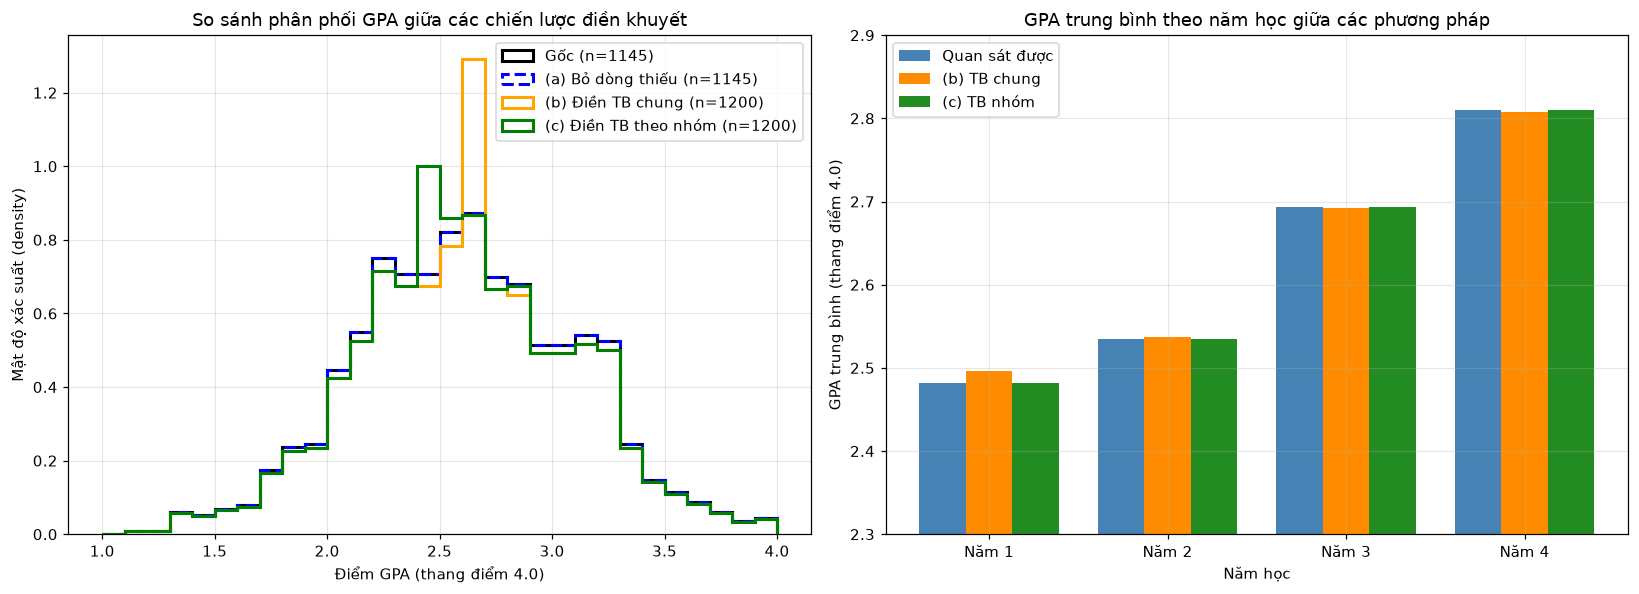

Task 4 ĐẠT.


In [16]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)
ax1.hist(original.dropna(), bins=bins, histtype="step", density=True, linewidth=2, label="Gốc (n=1145)", color="black")
ax1.hist(A, bins=bins, histtype="step", density=True, linewidth=2, linestyle="--", label="(a) Bỏ dòng thiếu (n=1145)", color="blue")
ax1.hist(B, bins=bins, histtype="step", density=True, linewidth=2, label="(b) Điền TB chung (n=1200)", color="orange")
ax1.hist(C, bins=bins, histtype="step", density=True, linewidth=2, label="(c) Điền TB theo nhóm (n=1200)", color="green")
ax1.set_xlabel("Điểm GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ xác suất (density)")
ax1.set_title("So sánh phân phối GPA giữa các chiến lược điền khuyết")
ax1.legend()

x = np.arange(len(by_year))
w = 0.26
ax2.bar(x - w, by_year["quan sát được"], width=w, label="Quan sát được", color="steelblue")
ax2.bar(x, by_year["(b) TB chung"], width=w, label="(b) TB chung", color="darkorange")
ax2.bar(x + w, by_year["(c) TB nhóm"], width=w, label="(c) TB nhóm", color="forestgreen")
ax2.set_xticks(x)
ax2.set_xticklabels([f"Năm {y}" for y in by_year.index])
ax2.set_ylim(2.3, 2.9)
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA trung bình (thang điểm 4.0)")
ax2.set_title("GPA trung bình theo năm học giữa các phương pháp")
ax2.legend()

fig.tight_layout()
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")


### Kết luận của bạn

> *(Nhấp đúp để sửa.)*

1. **Tỉ lệ thiếu `gpa` không đều giữa các năm học. Con số cụ thể:**
   - Năm 1: thiếu **10.80%** (39/361 sinh viên)
   - Năm 2: thiếu **2.83%** (9/318 sinh viên)
   - Năm 3: thiếu **1.40%** (4/285 sinh viên)
   - Năm 4: thiếu **1.27%** (3/236 sinh viên)

2. **Nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại? Vì sao điều đó nguy hiểm?**
   - Nhóm thiếu nhiều nhất (năm 1) có GPA trung bình quan sát được là **2.4815**, thấp hơn hẳn so với các năm trên (Năm 2: 2.5352, Năm 3: 2.6937, Năm 4: 2.8095). Điều này cực kỳ nguy hiểm vì dữ liệu bị thiếu có tính hệ thống (Missing Not At Random / MAR theo nhóm năm học). Nếu không nhận diện được điều này, các phân tích sẽ cho ra kết quả sai lệch nghiêm trọng.

3. **Chiến lược (a) làm gì với thành phần mẫu? Nhìn tỷ trọng sinh viên năm 1 trước/sau.**
   - Chiến lược (a) loại bỏ dòng thiếu làm giảm mạnh tỷ trọng sinh viên năm 1 từ **30.08%** xuống còn **28.12%**. Điều này làm biến dạng cơ cấu mẫu đại diện ban đầu của trường.

4. **Chiến lược (b) giữ nguyên trung bình chung 2.6148 — nghe có vẻ an toàn. Nhưng nhìn bảng theo từng năm: nó làm gì với trung bình của năm 1?**
   - Chiến lược (b) gán giá trị trung bình toàn trường 2.6148 vào 39 sinh viên năm 1 bị thiếu, khiến GPA trung bình của khối năm 1 bị kéo tăng giả tạo từ **2.4815 lên 2.4959** (lệch +0.0143 điểm). Nghe có vẻ toàn trường không đổi, nhưng cấu trúc nội tại của nhóm năm 1 đã bị bóp méo.

5. **Vì sao `std` giảm ở cả (b) và (c)? Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy?**
   - Cả hai phương pháp đều điền một giá trị đơn lẻ lặp lại nhiều lần vào 55 vị trí thiếu, làm giảm phương sai tự nhiên của dữ liệu và khiến độ lệch chuẩn (`std`) giảm giả tạo (từ 0.4871 xuống ~0.476). Hệ quả là khi tính khoảng tin cậy hoặc kiểm định giả thuyết thống kê, sai số chuẩn (SE) bị thu hẹp giả tạo, làm tăng nguy cơ mắc sai lầm loại I (kết luận có ý nghĩa thống kê trong khi thực tế không có).

6. **Cách nào ít làm méo nhất, và vì sao?**
   - Chiến lược **(c) — Điền bằng trung bình theo nhóm năm học** là phương án ít làm méo nhất. Nó giữ nguyên GPA trung bình chuẩn xác của từng khối năm học như dữ liệu quan sát được, bảo toàn cỡ mẫu đủ 1200 sinh viên và không làm thay đổi tỷ trọng thành phần mẫu giữa các năm học.

7. **Theo bạn vì sao sinh viên năm 1 thiếu GPA nhiều hơn hẳn? Nếu giả thuyết của bạn đúng thì cách xử lý đúng nhất có còn là "điền" nữa không?**
   - Sinh viên năm 1 thiếu nhiều vì các em mới nhập học, chưa thi xong hoặc chưa tích lũy đủ học phần để tính điểm GPA học kỳ. Nếu giả thuyết này đúng, bản chất là các em **chưa phát sinh điểm** chứ không phải dữ liệu bị thất lạc. Do đó cách xử lý đúng đắn nhất trong thực tế không phải là "điền khuyết" (imputation) mà là giữ nguyên giá trị rỗng kèm nhãn trạng thái riêng: `"Chưa tích lũy điểm"`.


---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

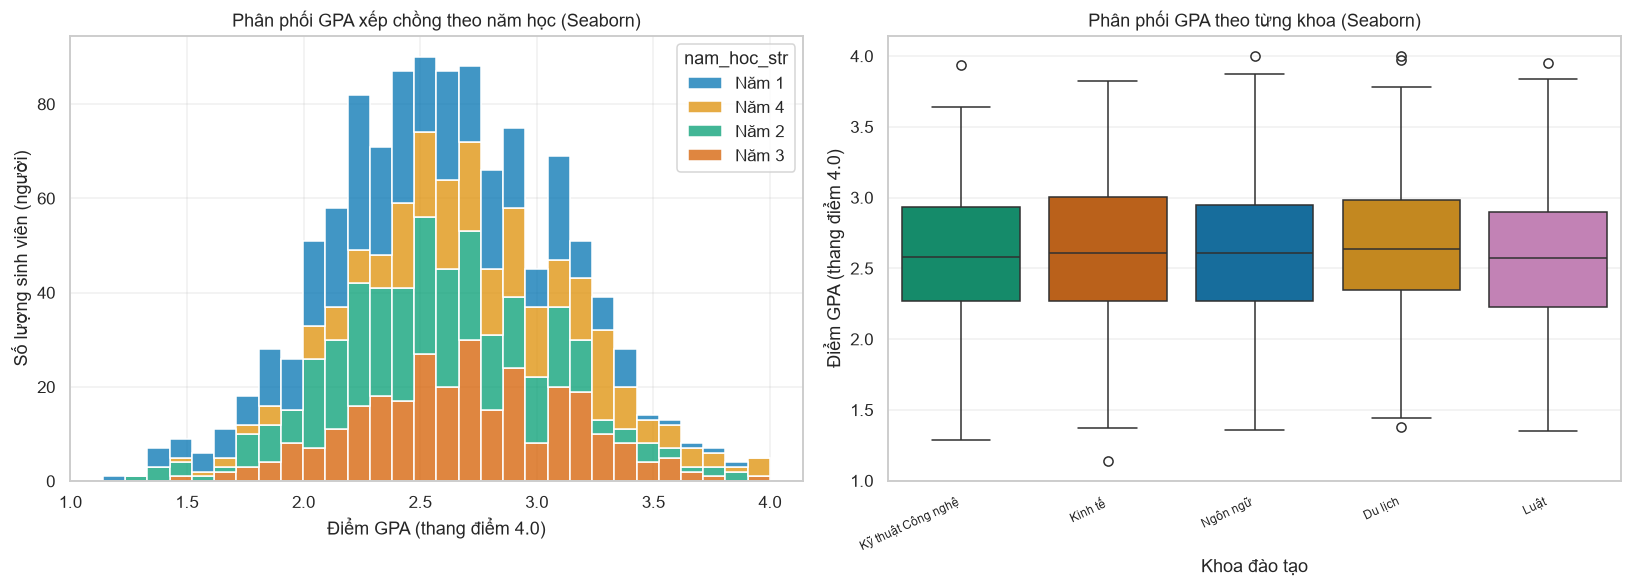

In [17]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

sv_plot = sv_gpa.copy()
sv_plot["nam_hoc_str"] = "Năm " + sv_plot["nam_hoc"].astype(str)
sns.histplot(data=sv_plot, x="gpa", hue="nam_hoc_str", bins=30, multiple="stack",
             palette="colorblind", ax=axa)
axa.set_xlabel("Điểm GPA (thang điểm 4.0)")
axa.set_ylabel("Số lượng sinh viên (người)")
axa.set_title("Phân phối GPA xếp chồng theo năm học (Seaborn)")

fac_order = sv["khoa"].value_counts().index.tolist()
sns.boxplot(data=sv_gpa, x="khoa", y="gpa", order=fac_order, hue="khoa",
            palette="colorblind", legend=False, ax=axb)
axb.set_xlabel("Khoa đào tạo")
axb.set_ylabel("Điểm GPA (thang điểm 4.0)")
axb.set_title("Phân phối GPA theo từng khoa (Seaborn)")
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác


### Bản nào truyền đạt tốt hơn?

> *(Nhấp đúp để sửa. Đừng trả lời "Seaborn đẹp hơn" — hãy nói **bản nào giúp người đọc trả lời câu hỏi nhanh hơn**, và đánh đổi là gì.)*

1. **Bản Seaborn cho bạn thêm thông tin gì mà bản matplotlib ở Task 1 không có?**
   - Bản Seaborn cho phép trực quan hóa đa chiều: phân phối GPA được xếp chồng theo từng khối năm học (`hue="nam_hoc"`), giúp người đọc nhìn thấy ngay sinh viên năm 1 tập trung ở dải điểm thấp hơn trong khi sinh viên năm 3, 4 dịch chuyển dần về phía điểm cao.

2. **Có thông tin nào bản matplotlib thể hiện rõ hơn không?**
   - Bản matplotlib đơn giản thể hiện hình dạng tổng thể của toàn bộ phân phối dữ liệu (đường bao phân phối chuẩn của toàn trường) rõ ràng hơn mà không bị phân tán thị giác bởi các dải màu của các nhóm con.

3. **Bao nhiêu dòng code mỗi bản? Đánh đổi giữa số dòng và khả năng kiểm soát nằm ở đâu?**
   - Bản Seaborn chỉ mất khoảng 2-3 dòng code ngắn gọn do được tích hợp sẵn việc gom nhóm, ánh xạ bảng màu và tính toán phân phối. Đánh đổi lại, Matplotlib thuần cho phép kiểm soát tuyệt đối từng chi tiết nhỏ (từng vạch tick, ranh giới cột, định dạng nhãn chuyên biệt) mà không bị phụ thuộc vào các thiết lập mặc định của thư viện cấp cao.

4. **Nếu phải đưa một trong hai vào báo cáo gửi Ban Giám hiệu, bạn chọn bản nào, vì sao?**
   - Tôi chọn **bản Seaborn**. Lý do là biểu đồ xếp chồng cung cấp cái nhìn sâu sắc và có giá trị quản trị cao hơn: Ban Giám hiệu không chỉ thấy phổ điểm toàn trường mà còn thấy được bức tranh tiến bộ học tập rõ rệt của sinh viên qua các năm, đồng thời bảng màu `colorblind` đảm bảo tính chuyên nghiệp và khả năng tiếp cận hình ảnh tối ưu.


---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [x] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [x] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [x] `banhang_sach.csv` — 900 dòng × 8 cột
- [x] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [x] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [x] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [x] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [x] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [x] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [x] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [x] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không? **Có, hoàn toàn lặp lại được 100%.**
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? **Không, mọi quyết định đều có căn cứ phân tích định lượng rõ ràng.**
